# Logistic Regression : Direct Marketing in Banking

## 1. Introduction

This is an example on how to implement logistic regression to predict wheather a client will subscribe to a term deposit as a result of direct marketing campaigns (phone calls). The dfset if from the UIC Machine Learning Repository.  


## 2. About Logistic Regression

Logistic regression is basically a machine learning classification algorithm used to predict the probability of a categorical dependent variable. Thus, it predicts P(Y=1) as a function of x. Note that the dependent variable is binary (0 or 1).

**Main Assumptions**

1. Independent variables should have no multicollinearity
2. Independent variables have a linear relationship to log odds
3. Sample sizes are large

## 3. Code

Let us take a look at the code.

### 3.1 Setting the environment

Importing packages:
  

In [19]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font",size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid",color_codes=True)

### 3.2 Importing df & Inspection

Let us import the df and inspect the same  

In [50]:
## Importing the df (in CSV format)
df = pd.read_csv('banking.csv', header = 0)


print(df.shape)
print(list(df.columns))

(41188, 21)
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']


In [51]:
## Inspecting the df
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


### 3.3 Understanding the df in hand

#### 3.3.1 Input variables

1.age (numeric)  
2.job : type of job (categorical: “admin”, “blue-collar”, “entrepreneur”, “housemaid”, “management”, “retired”, “self-employed”, “services”, “student”, “technician”, “unemployed”, “unknown”)  
3.marital : marital status (categorical: “divorced”, “married”, “single”, “unknown”)  
4.education (categorical: “basic.4y”, “basic.6y”, “basic.9y”, “high.school”, “illiterate”, “professional.course”, “university.degree”, “unknown”)  
5.default: has credit in default? (categorical: “no”, “yes”, “unknown”)  
6.housing: has housing loan? (categorical: “no”, “yes”, “unknown”)  
7.loan: has personal loan? (categorical: “no”, “yes”, “unknown”)  
8.contact: contact communication type (categorical: “cellular”, “telephone”)  
9.month: last contact month of year (categorical: “jan”, “feb”, “mar”, …, “nov”, “dec”)  
10.day_of_week: last contact day of the week (categorical: “mon”, “tue”, “wed”, “thu”, “fri”)  
11.duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y=’no’). The duration is not known before a call is performed, also, after the end of the call, y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model  
12.campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
13.pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)  
14.previous: number of contacts performed before this campaign and for this client (numeric)  
15.poutcome: outcome of the previous marketing campaign (categorical: “failure”, “nonexistent”, “success”)  
16.emp.var.rate: employment variation rate — (numeric)  
17.cons.price.idx: consumer price index — (numeric)  
18.cons.conf.idx: consumer confidence index — (numeric)  
19.euribor3m: euribor 3 month rate — (numeric)  
20.nr.employed: number of employees — (numeric)  

#### 3.3.2 Target Variable  

y — has the client subscribed a term deposit? (binary: “1”, means “Yes”, “0” means “No”)

#### 3.3.3 Bucketing : Education

Education has many categories. We are going to reduce it for better modeling.

In [52]:
df['education'].unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

In [53]:
## Grouping basic - 4,6 and 9 years into basic

df['education']=np.where(df['education']=='basic.9y','Basic',df['education'])
df['education']=np.where(df['education']=='basic.6y','Basic',df['education'])
df['education']=np.where(df['education']=='basic.4y','Basic',df['education'])

In [54]:
## Looking at the education field again

df['education'].unique()

array(['Basic', 'unknown', 'university.degree', 'high.school',
       'professional.course', 'illiterate'], dtype=object)

### 3.4 Exploratory df Analysis

#### 3.4.1 Target Variable

Let us understand the target variable first

In [55]:
df['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

<ipython-input-56-4c77d0f2ece8>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y',data=df,palette='hls')


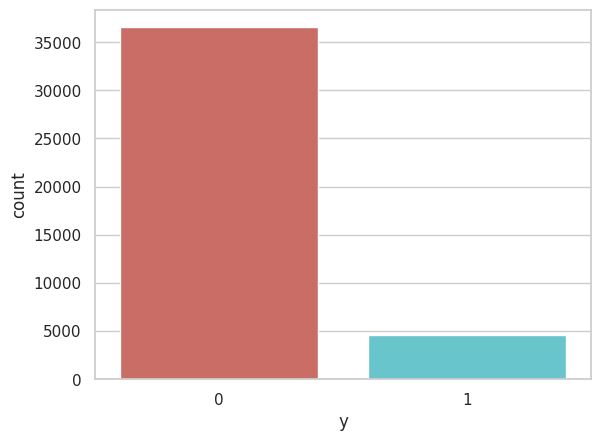

<Figure size 640x480 with 0 Axes>

In [56]:
sns.countplot(x='y',data=df,palette='hls')
plt.show()
plt.savefig('count_plot')

Thus we have 36548 cases of 'no success', and '4640' cases of success.

Let us understand how the mean values are, for both the classes.



In [57]:
## df Summarization

# Separate the dfFrame into numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Group by the target variable and calculate the mean of numeric columns
mean_values_by_group = df.groupby('y')[numeric_cols].mean()

# Display the mean values by group
print("Mean values by group for numeric columns:")
print(mean_values_by_group)

# For categorical columns, we can display the mode or frequency count
categorical_values_by_group = df.groupby('y')[categorical_cols].agg(lambda x: x.mode().iloc[0])

print("\nMode values by group for categorical columns:")
print(categorical_values_by_group)

Mean values by group for numeric columns:
         age    duration  campaign       pdays  previous  emp_var_rate  \
y                                                                        
0  39.911185  220.844807  2.633085  984.113878  0.132374      0.248875   
1  40.913147  553.191164  2.051724  792.035560  0.492672     -1.233448   

   cons_price_idx  cons_conf_idx  euribor3m  nr_employed    y  
y                                                              
0       93.603757     -40.593097   3.811491  5176.166600  0.0  
1       93.354386     -39.789784   2.123135  5095.115991  1.0  

Mode values by group for categorical columns:
      job  marital          education default housing loan   contact month  \
y                                                                            
0  admin.  married              Basic      no     yes   no  cellular   may   
1  admin.  married  university.degree      no     yes   no  cellular   may   

  day_of_week     poutcome  
y               

** OBSERVATIONS: **

1. Average age of people who converted as higher than those who didn't
2. People who converted were engaged for a longer duration over the call
3. People who converted were exposed to fewer campaigns than those who didn't


### 3.4.2 df Visualization

** 1. Purchase by job type **  

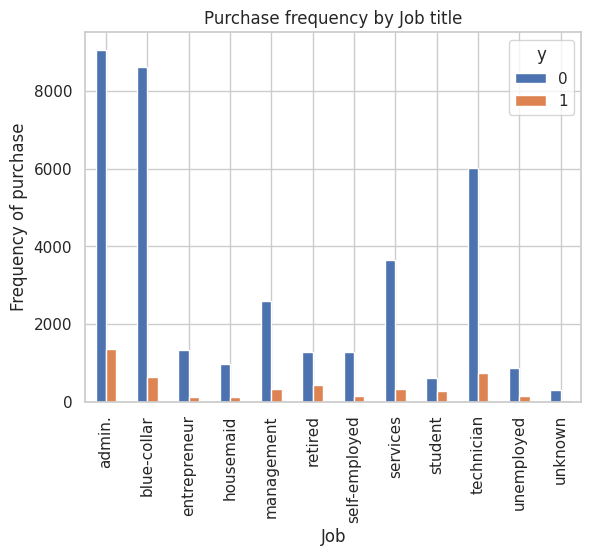

In [58]:
%matplotlib inline
pd.crosstab(df.job,df.y).plot(kind='bar')
plt.title('Purchase frequency by Job title')
plt.xlabel('Job')
plt.ylabel('Frequency of purchase')
plt.savefig('purchase_by_job')

Thus jobs seem to be an important predictor variable.

** 2. Purchase by marital status **


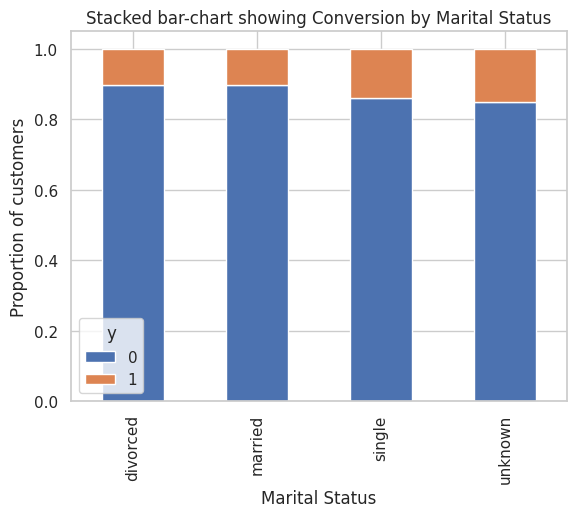

In [59]:
%matplotlib inline
table = pd.crosstab(df.marital,df.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked bar-chart showing Conversion by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Proportion of customers')
plt.savefig('purchase_by_ms')

THere is not variation within each of the classes, and hence doesnt seem to be an important predictor variable.

** 3. Purchase by education **

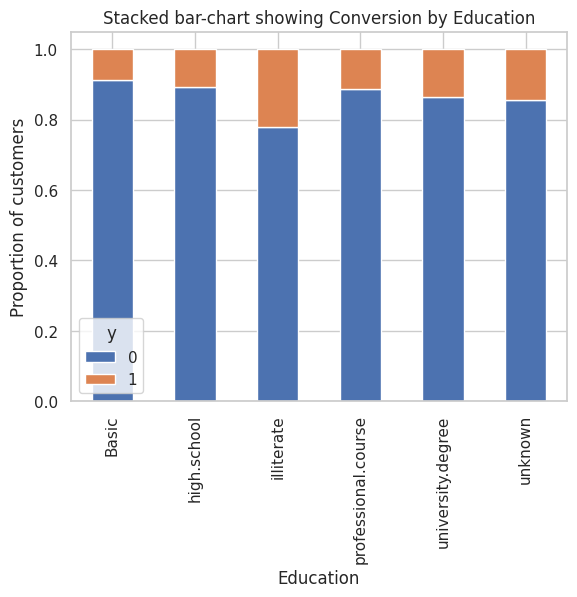

In [60]:
%matplotlib inline
table = pd.crosstab(df.education,df.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked bar-chart showing Conversion by Education')
plt.xlabel('Education')
plt.ylabel('Proportion of customers')
plt.savefig('purchase_by_edu')

Education seems to be important in predicting the success - illiterate people being convinced more by such marketing calls.

** 4. Purchase quantity by Month **


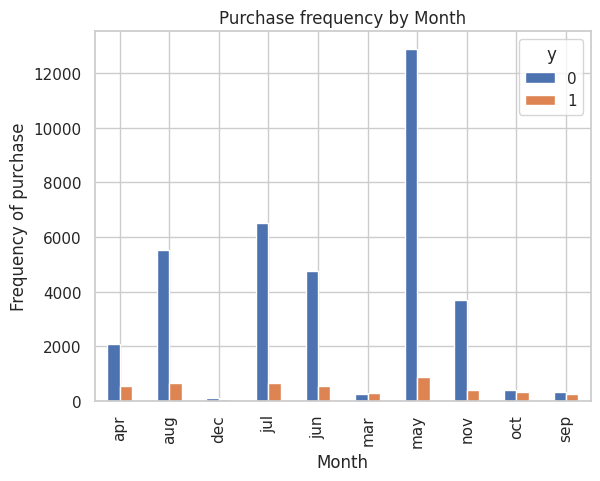

In [61]:
%matplotlib inline
pd.crosstab(df.month,df.y).plot(kind='bar')
plt.title('Purchase frequency by Month')
plt.xlabel('Month')
plt.ylabel('Frequency of purchase')
plt.savefig('purchase_by_mnt')

The number of conversions seem to be seasonal, and months seem to play an important role.

** 5. Understanding the Day of Week effect **

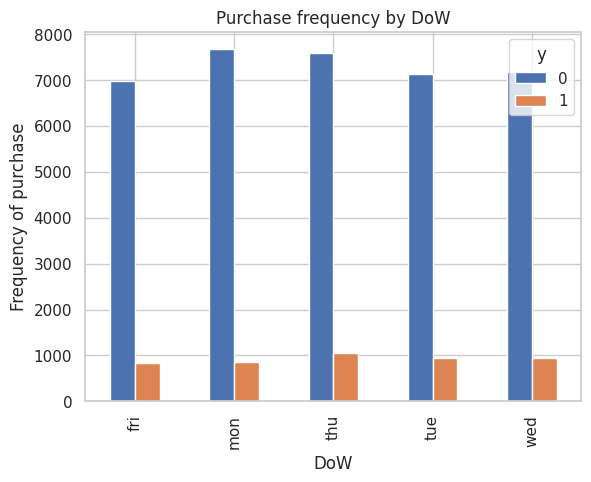

In [62]:
%matplotlib inline
pd.crosstab(df.day_of_week,df.y).plot(kind='bar')
plt.title('Purchase frequency by DoW')
plt.xlabel('DoW')
plt.ylabel('Frequency of purchase')
plt.savefig('purchase_by_dow')

Thus Day of Week doen't seem to contain much information, and hence might not be a good predictor variable.

** 6. Purchase frequency by Previous outcomes**

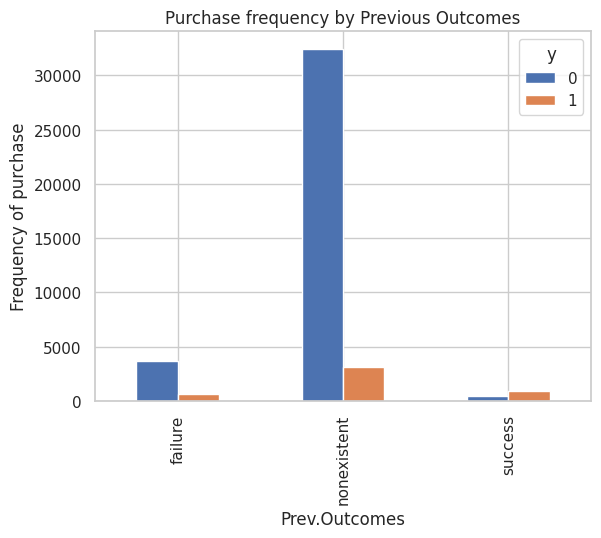

In [63]:
%matplotlib inline
pd.crosstab(df.poutcome,df.y).plot(kind='bar')
plt.title('Purchase frequency by Previous Outcomes')
plt.xlabel('Prev.Outcomes')
plt.ylabel('Frequency of purchase')
plt.savefig('purchase_by_pout')

Thus, new target customers seem to convert more. Also, previous outcomes seem to be an important variable in prediction.

### 3.5 Creating Dummy Variables

Since lot of fields are categorical, let us code them into dummy variables. These dummy variables contain binary values.

In [64]:
categorical_variable_cols = ['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome']

for var in categorical_variable_cols:
    categ_list = 'var_' + var
    categ_list = pd.get_dummies(df[var],prefix = var)
    df1=df.join(categ_list)
    df = df1

## Creating feilds to keep
df_vars = df.columns.values.tolist()
to_keep=[i for i in df_vars if i not in categorical_variable_cols]

** Final columns to keep**

In [98]:
df_final = df[to_keep]
df_final = df_final.dropna(subset=['y'])
df_final.columns.values

array(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student',
       'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_Basic', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_no',
       'default_unknown', 'default_yes', 'housing_no', 'housing_unknown',
       'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',

** Setting the X & Y values **

In [99]:
df_final_vars = df_final.columns.values.tolist()
y = df_final['y']
X = df_final.drop('y', axis=1)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 72 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   job                            41188 non-null  object 
 2   marital                        41188 non-null  object 
 3   education                      41188 non-null  object 
 4   default                        41188 non-null  object 
 5   housing                        41188 non-null  object 
 6   loan                           41188 non-null  object 
 7   contact                        41188 non-null  object 
 8   month                          41188 non-null  object 
 9   day_of_week                    41188 non-null  object 
 10  duration                       41188 non-null  int64  
 11  campaign                       41188 non-null  int64  
 12  pdays                          41188 non-null 

In [101]:
# Convert y to a 1D array
y = y.map({'yes': 1, 'no': 0})

y = y.values.ravel()

# Handle any remaining NaN values in features by filling with a default value (e.g., median for numeric, 'missing' for categorical)
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())
X[categorical_features] = X[categorical_features].fillna('missing')

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Preprocess numeric features
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Preprocess categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_encoded = encoder.fit_transform(X[categorical_features])

# Combine numeric and encoded categorical features
X_processed = np.hstack((X[numeric_features], X_encoded))


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 72 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   job                            41188 non-null  object 
 2   marital                        41188 non-null  object 
 3   education                      41188 non-null  object 
 4   default                        41188 non-null  object 
 5   housing                        41188 non-null  object 
 6   loan                           41188 non-null  object 
 7   contact                        41188 non-null  object 
 8   month                          41188 non-null  object 
 9   day_of_week                    41188 non-null  object 
 10  duration                       41188 non-null  int64  
 11  campaign                       41188 non-null  int64  
 12  pdays                          41188 non-null 

### 3.6 Feature Selection

For the purpose of feature selection, the method impletened here is **RFE (Recursive Feature Elimination)**.  

RFE selects features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through a *coef_* attribute or through a *feature_importances_* attribute. Then, the least important features are pruned from current set of features.That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.

In [106]:
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


logreg = LogisticRegression(max_iter=4000, solver='liblinear')

# df_final = df_final.dropna(subset=['y'])
rfe = RFE(estimator = logreg, n_features_to_select=5)
rfe = rfe.fit(X_processed, df_final['y'])

Selected_Features_Support = list(rfe.support_)
Selected_Features_rank = list(rfe.ranking_)

print("Selected Features Support:", Selected_Features_Support)
print("Selected Features Rank:", Selected_Features_rank)

# Create a DataFrame to see which features were selected
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(encoded_feature_names)
selected_features = pd.DataFrame({
    'Feature': feature_names,
    'Support': Selected_Features_Support,
    'Rank': Selected_Features_rank
})
print(selected_features)

Selected Features Support: [False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False]
Selected Features Rank: [107, 1, 38, 32, 78, 1, 3, 44, 7, 43, 22, 99, 73, 41, 103, 57, 31, 102, 27, 88, 15, 24, 104, 60, 96, 61, 17, 26, 23, 108, 25, 95, 30, 87, 58, 83, 59, 82, 47, 105, 55, 98

The RFE has helped us select the following features: “previous”, “euribor3m”, “job_blue-collar”, “job_retired”, “job_services”, “job_student”, “default_no”, “month_aug”, “month_dec”, “month_jul”, “month_nov”, “month_oct”, “month_sep”, “day_of_week_fri”, “day_of_week_wed”, “poutcome_failure”, “poutcome_nonexistent”, “poutcome_success”.

Selecting only these columns:

In [107]:
columns_final = ["previous", "euribor3m", "job_blue-collar", "job_retired", "job_services", "job_student", "default_no",
      "month_aug", "month_dec", "month_jul", "month_nov", "month_oct", "month_sep", "day_of_week_fri", "day_of_week_wed",
      "poutcome_failure", "poutcome_nonexistent", "poutcome_success"]

X = df_final[columns_final]
y = df_final['y']

### 3.7 Model Implementation

Running the final model with the selected features.

** Train vs Test : 70% vs 30%**

In [72]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state=0)


** Creating the final model : **

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

logreg = LogisticRegression()

logreg.fit(X_train, y_train)

LogisticRegression()

** Predicting the test set results, and calculating the accuracy**


In [74]:
y_pred = logreg.predict(X_test)

## Calculating the accuracy

print('Accuracy of logistic regression classifier on test set: {:2f}'.format(logreg.score(X_test,y_test)))

Accuracy of logistic regression classifier on test set: 0.900461


### 3.8 Cross Validation to make sure that the model generalizes well

In-order to make sure that the model doesn't overfit, we will do a 10-fold CV to train our logistic regression model.

In [76]:
from sklearn import model_selection
from sklearn.model_selection import cross_val_score

kfold = model_selection.KFold(n_splits = 10, random_state = 7, shuffle= True)

modelCV = LogisticRegression()

scoring = 'accuracy'

results = model_selection.cross_val_score(modelCV, X_train,y_train, cv = kfold, scoring = scoring)

print("10-fold cross-validation average accuracy : %.3f" % (results.mean()))

10-fold cross-validation average accuracy : 0.897


Thus the average accuracy after CV is very close to the accuracy predicted from the test set.

Hence, we can conclude that our model generalizes well.
  
  
### 3.9 Creating the truth table (Confusion Matrix)  


In [77]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[10872   109]
 [ 1121   255]]


Thus, True Positive = 10872, False Positive = 1122, True Negative = 254, False Negative = 109

Precision = TP/(TP+FP)  

Recall = TP/(TP+FN)  

F score = 2 * (Precision * Recall)/(Precision + Recall)

** Calculating Precission, Recall & F1 score**

In [78]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10981
           1       0.70      0.19      0.29      1376

    accuracy                           0.90     12357
   macro avg       0.80      0.59      0.62     12357
weighted avg       0.88      0.90      0.87     12357



Thus the model has a high overall precision and recall, and F-score.